In [1]:
%cd ..
from deepmrac.image_processing import sort_dicomfiles, load_and_resample_images, resample_to_output_format, convert_dicom_to_nifti, to_dcm, convert_interfile_to_nifti, to_interfile, transform_ct_to_mu511
from deepmrac.predictions import predict_DeepDixon
from deepmrac.metrics import save_metrics_to_csv, calculate_quality_metrics
import nibabel as nib
import os

/Users/anne-gabrielle/Le_Neuro/DeepMRAC


In [2]:
tmpdir="./temp_file"
inphase_path="./datasets/REMIND_022/Dixon/HEAD_DIXON_60MINLIST_PET_IN_0003"
opposedphase_path="./datasets/REMIND_022/Dixon/HEAD_DIXON_60MINLIST_PET_OPP_0004"
umap_path="./datasets/REMIND_022/Dixon/HEAD_DIXON_60MINLIST_PET_IN_UMAP_0007"
verbose=True
version='VE11P'
output_folder=f"./output/Dixon/test"
ct_path=None
ct_kvp=120

In [3]:
# Sort files into specific folders
sort_dicomfiles(source_folder=inphase_path, temp_subfolder=f"{tmpdir}/inphase_dcm", verbose=verbose )
sort_dicomfiles(source_folder=opposedphase_path, temp_subfolder=f"{tmpdir}/opposedphase_dcm", verbose=verbose )

Principal Serie identified : 1.3.12.2.1107.5.2.38.51018.2017081113422025193895193.0.0.0 (128 images)
Principal Serie identified : 1.3.12.2.1107.5.2.38.51018.2017081113422113221095851.0.0.0 (128 images)


In [4]:
# Load and resample data
convert_dicom_to_nifti(dicom_dir=f"{tmpdir}/inphase_dcm", output_nii=f"{tmpdir}/inphase.nii.gz", verbose=verbose)
convert_dicom_to_nifti(dicom_dir=f"{tmpdir}/opposedphase_dcm", output_nii=f"{tmpdir}/opposedphase.nii.gz", verbose=verbose)


Converting ./temp_file/inphase_dcm to ./temp_file/inphase.nii.gz
Converting ./temp_file/opposedphase_dcm to ./temp_file/opposedphase.nii.gz


In [5]:
# --- Process UMAP (Conditional: DICOM or Interfile) ---
# Check if there's an Interfile header in the source folder
interfile_headers = [f for f in os.listdir(umap_path) if f.lower().endswith('.i.hdr')]

if interfile_headers:
    if verbose:
        print(f"Detected Interfile format for UMAP in {umap_path}")
            
    # We take the first header found
    hdr_full_path = os.path.join(umap_path, interfile_headers[0])

    convert_interfile_to_nifti(hdr_path=hdr_full_path, output_nii_path=f"{tmpdir}/umap.nii.gz")

else:
    if verbose:
        print(f"Detected DICOM format for UMAP in {umap_path}")
                
    # Standard sorting for DICOM files
    sort_dicomfiles(source_folder=umap_path, temp_subfolder=f"{tmpdir}/umap_dcm", verbose=verbose)
    convert_dicom_to_nifti(dicom_dir=f"{tmpdir}/umap_dcm", output_nii=f"{tmpdir}/umap.nii.gz", verbose=verbose)

Detected DICOM format for UMAP in ./datasets/REMIND_022/Dixon/HEAD_DIXON_60MINLIST_PET_IN_UMAP_0007
Principal Serie identified : 1.3.12.2.1107.5.2.38.51018.201708111342459148698522.0.0.0 (128 images)
Converting ./temp_file/umap_dcm to ./temp_file/umap.nii.gz


In [6]:
inphase_rsl, inphase_ref = load_and_resample_images(nii_image=f"{tmpdir}/inphase.nii.gz", verbose=verbose)
opposedphase_rsl, opposedphase_ref = load_and_resample_images(nii_image=f"{tmpdir}/opposedphase.nii.gz", verbose=verbose)
umap_nat = nib.load(f'{tmpdir}/umap.nii.gz')

Loading and resampling data from ./temp_file/inphase.nii.gz.
Loading and resampling data from ./temp_file/opposedphase.nii.gz.


In [7]:
pred = predict_DeepDixon(inphase=inphase_rsl, opposedphase=opposedphase_rsl, version=version)
pred = pred / 10000 # convert back to umap's units

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 

In [8]:
# Resample to Umap Formatos.makedirs(output_folder, exist_ok=True)
pred_nii = nib.Nifti1Image(pred, inphase_ref.affine, inphase_ref.header)
os.makedirs(output_folder, exist_ok=True)
DeepX_nii = resample_to_output_format(pred_nii=pred_nii, umap_native=umap_nat, verbose=verbose, output_file=f"{output_folder}/DeepDixon.nii.gz")
       

Resampling to Umap format.
Saving QC nii file to ./output/Dixon/test/DeepDixon.nii.gz.


In [9]:
# Final DICOM (using Umap as container)
if interfile_headers:
    to_interfile(DeepX_nii=DeepX_nii, hdr_template=hdr_full_path, output_path=f"{output_folder}/DeepDixon", rmi_type="Dixon")
else:
    to_dcm(DeepX_nii=DeepX_nii, dcmcontainer=f"{tmpdir}/umap_dcm", dicomfolder=f"{output_folder}/DeepDixon", rmi_type="Dixon")
                

# Visualisation

In [10]:
from deepmrac.plots import plot_comparison

Plot saved to: ./output/Dixon/test/comparison_plot.png


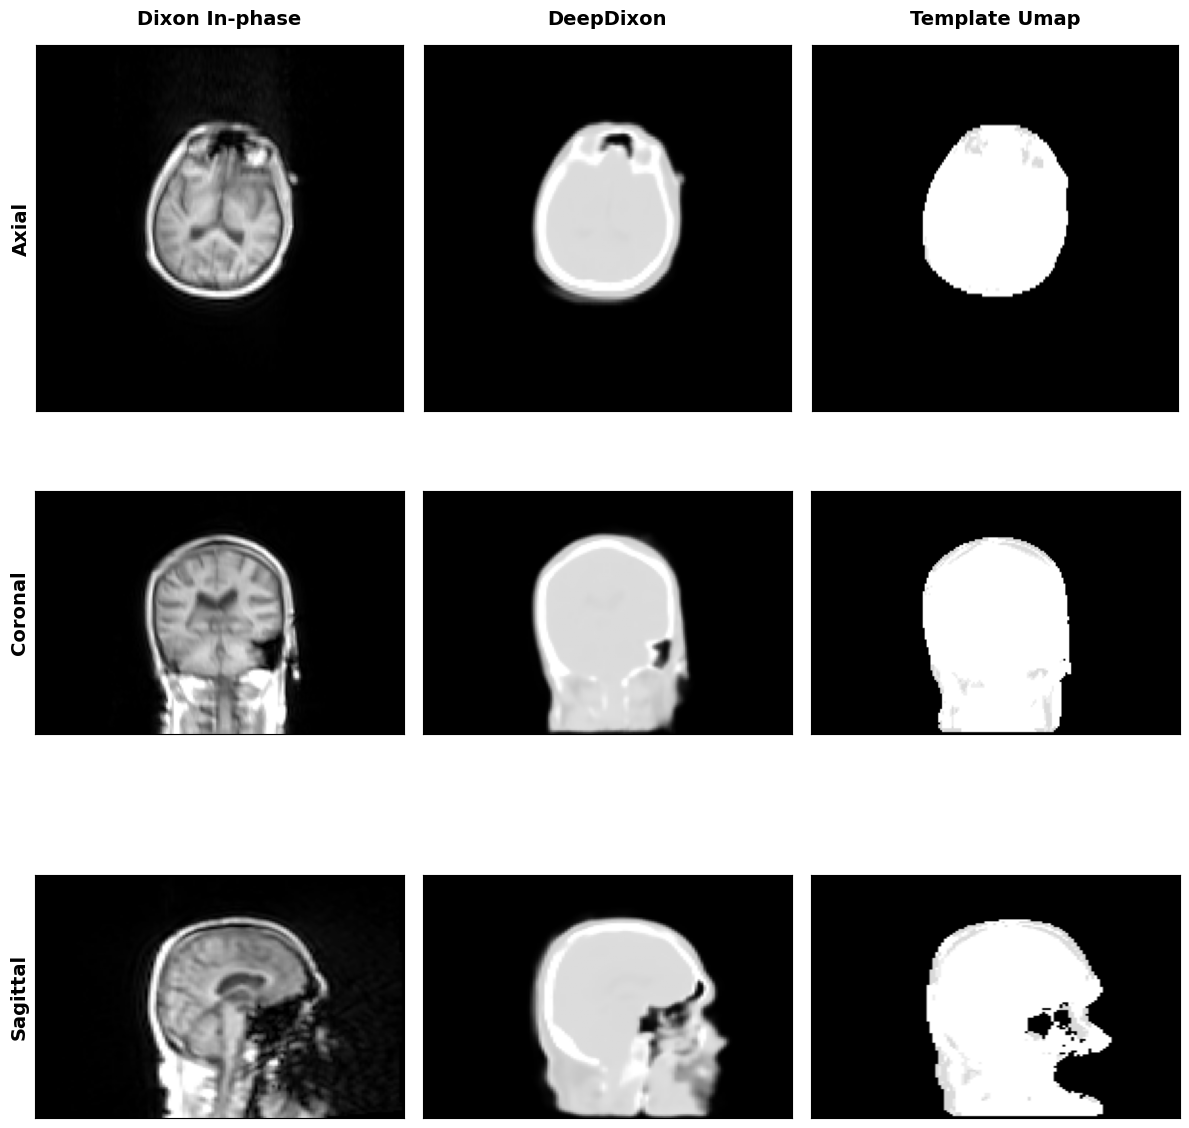

In [13]:
plot_comparison(input_path=f"{tmpdir}/inphase.nii.gz", prediction_path=f"{output_folder}/DeepDixon.nii.gz", template_umap_path=f'{tmpdir}/umap.nii.gz', model_type="Dixon", output_path=f"{output_folder}/comparison_plot.png")